In [39]:
import os
import sys
import torch
import torchvision
import yaml
import tqdm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import torchvision.models as models

from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix

from utils.data_utils import get_data, get_gen

# set directory to parent directory
os.chdir("/Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae")

# print current working directory
print("Current Working Directory:", os.getcwd())


Current Working Directory: /Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae


# Pretrain CIFAR-10 Classification Model

In [40]:
configs = {
    "data": {
        "data_name": "cifar10",
        "num_clusters_data": 10,
    },
    "training": {
        "batch_size": 256,
        "augment": False,
        "augmentation_method": 'simple',
        "aug_decisions_weight": 1,
    },
    "globals": {
        "seed": 42,
    }
}

In [41]:

# Dataset
trainset, trainset_eval, testset = get_data(configs)

gen_train = get_gen(trainset, configs, validation=False, shuffle=False)
gen_train_eval = get_gen(trainset_eval, configs, validation=True, shuffle=False)
gen_test = get_gen(testset, configs, validation=True, shuffle=False)

gen_train_eval_iter = iter(gen_train_eval)
gen_test_iter = iter(gen_test)

y_train = trainset_eval.dataset.targets.clone().detach()[trainset_eval.indices].numpy()
y_test = testset.dataset.targets.clone().detach()[testset.indices].numpy()

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


In [42]:
print("Trainset shape:", trainset.dataset.data.shape)
print("Number of samples in trainset:", len(gen_train.dataset))

print("\nTrainset eval shape:", trainset_eval.dataset.data.shape)
print("Number of samples in trainset eval:", len(gen_train_eval.dataset))

print("\nTestset shape:", testset.dataset.data.shape)
print("Number of samples in testset:", len(gen_test.dataset))


Trainset shape: (50000, 32, 32, 3)
Number of samples in trainset: 50000

Trainset eval shape: (50000, 32, 32, 3)
Number of samples in trainset eval: 50000

Testset shape: (10000, 32, 32, 3)
Number of samples in testset: 10000


In [45]:
# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model 
model = models.resnet50(pretrained=True)
model = model.to(device)

# loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# epochs
n_epochs = 10

# Training
model.train()
for epoch in tqdm.tqdm(range(n_epochs)):
    for i, (x_batch, y_batch) in enumerate(gen_train):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(x_batch)

        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        # use gen_train_eval to evaluate the model
        if i % 10 == 0:
            model.eval()
            with torch.no_grad():
                x_batch_eval, y_batch_eval = next(gen_train_eval_iter)
                x_batch_eval, y_batch_eval = x_batch_eval.to(device), y_batch_eval.to(device)

                y_pred_eval = model(x_batch_eval)
                loss_eval = criterion(y_pred_eval, y_batch_eval)

                print(f"Epoch: {epoch}, Batch: {i}, Loss: {loss.item()}, Loss eval: {loss_eval.item()}")
            model.train()


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0, Batch: 0, Loss: 13.30945110321045, Loss eval: 14.781968116760254
Epoch: 0, Batch: 10, Loss: 1.7483398914337158, Loss eval: 6.821011066436768


In [34]:
# Model Evaluation
model.eval()

with torch.no_grad():
    for i, (x, y) in enumerate(gen_test):
        if i == 0:
            y_pred = model(x)
        else:
            y_pred = torch.cat([y_pred, model(x)], dim=0)

y_pred = y_pred.argmax(dim=1).numpy()

y_test shape: (10000,)
Accuracy: 0.0


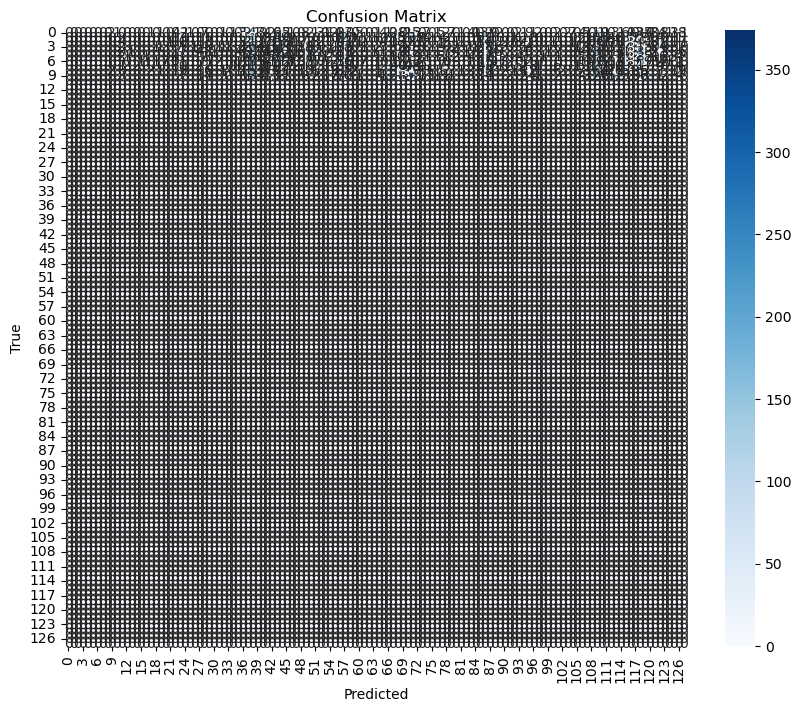

In [33]:

print("y_test shape:", y_test.shape)

# accuracy
acc = np.mean(y_pred == y_test)
print("Accuracy:", acc)

# confusion matrix


# Pretrain CIFAR-10 MNIST Model

# Pretrain CIFAR-10 FashionMNIST Model